# R3Con — results

Every table and figure in the paper, rebuilt from this repo's `logs/`. *Restart & Run All* to
reproduce. **No model is called and nothing is re-judged here** — each run's `score.json` was
written by the judge when the run happened, and this notebook only reads it back, so the
numbers are the same every time.

**Five sections:**

1. **Loong** — the long-context benchmark (S = avg 1–100 score, Accuracy = exact-match rate).
2. **CorpusQA** — the computation-heavy benchmark (0/1 accuracy).
3. **Cross-benchmark** — the phase ablations + downstream reasoning + totals + cost across both.
4. **Method internals** — how far R3Con's just-in-time representation compresses the input.
5. **Summary rounds (N)** — the accuracy/cost sweep over `summary_rounds`.

Each benchmark section defines its own display helpers and pins, so **run top-to-bottom**.
R3Con is always shown last.

In [1]:
import sys
from pathlib import Path
import pandas as pd

# `scoreboard` lives in analysis/ — importable whether Jupyter started here or at the repo root.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file())
if str(ROOT / "analysis") not in sys.path:
    sys.path.insert(0, str(ROOT / "analysis"))

from scoreboard import paths, report, meta, style, load
from IPython.display import display, Markdown
pd.set_option("display.max_columns", None)

**Shared config** — the defaults used by *both* benchmark sections; change them here to apply
everywhere. (Per-method colour / marker / display name live in `scoreboard.style`; R3Con's
default configuration — the coding agent, `summary_rounds = 2` — in `scoreboard.report`.)

In [2]:
KEEP_MODELS = {"qwen3-5-35b-a3b", "rl-memoryagent-14b",                     # served model + MemAgent's trained model
               "claude-opus-4-8", "claude-sonnet-4-6", "claude-sonnet-5"}   # frontier refs (Claude Code)
MIN_SCORED = 30                          # drop runs (by full RUN_KEY) with fewer graded tasks (wire-tests)
GROUNDED_NAME = style.GROUNDED_NAME      # the system's name — defined once in scoreboard.style
GROUNDED_METHOD = report.DEFAULT_METHOD  # the coding agent downstream (scoreboard.report)
GROUNDED_SR = report.DEFAULT_SR          # summary_rounds = 2
CLAUDE_MODEL = "claude-sonnet-4-6"       # CorpusQA Main frontier reference (Claude Code)

**Plot setup** — matplotlib + the shared `$`-tick formatter. Dollar cost appears in exactly two
figures: the cross-benchmark **Total cost** panels and the **R3Con vs. Claude Code** plot.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter, NullLocator

# One colour per BENCHMARK, shared by every figure whose series are benchmarks (summary rounds, the
# parse-cells and token distributions) so CorpusQA / Loong read the same across the paper. Validated as
# a categorical pair (dataviz validator, light surface): CVD ΔE 20.9, normal-vision ΔE 27.3 — all pass.
BENCH_COLOR = {"CorpusQA": "#2b6cb0", "Loong": "#c05621"}
# …and one HATCH per benchmark, so filled shapes stay identifiable without colour (colour-blind readers,
# greyscale print): 45° vs 135° lines — where two distributions overlap they read as a cross-hatch.
BENCH_HATCH = {"CorpusQA": "///", "Loong": "\\\\\\"}

# Shared $-tick formatter for the surviving cost figures: 1000 -> "$1k", 2000 -> "$2k"; below 1k "$200".
def _kdollar(v, _):
    return f"${v / 1000:g}k" if v >= 1000 else f"${v:,.0f}"

# Loong

- **S** = average judge score (1–100, context-window errors counted as the floor).
- **Accuracy** = exact-match / perfect rate (fraction scored exactly 100).

In [4]:
# One row per inference (+ Loong metadata), restricted to Loong, with readable run labels.
loong = report.add_labels(report.build().query("benchmark == 'loong'"))

# ReadAgent has a small parallel-lookup experiment (n≈53) alongside its canonical run — both carry
# variant='default', so drop the non-canonical one here (else it'd add a 2nd "ReadAgent" row).
loong = loong[~((loong["method"] == "readagent") & (loong["config"].str.contains("lookup_method=parallel", na=False)))]

# Drop the smallest context tier (set 1 = 10–50K tok) at the SOURCE — it's the easy regime where
# "just read the text" wins and isn't the interesting comparison. Excluding it on `loong` itself
# (not just `loong_real`) means EVERY downstream frame inherits it — the headline/keep step, the
# banded boards, the by-domain boards, the Totals, AND the cross-benchmark ablation table (which is
# handed `loong`) — so no code path can ever silently reintroduce set 1. Comment out this ONE line
# (and Restart & Run All) to include it again everywhere.
loong = loong[loong["set"] != 1]

# Center on the served vLLM model; keep claude-code's Opus + Sonnet as frontier references.
# Keep only runs (by full RUN_KEY) with enough graded tasks, dropping wire-tests.
# (KEEP_MODELS / MIN_SCORED come from the shared-config cell up top.)
h = report.headline(loong[loong["model"].isin(KEEP_MODELS)])
keep = h.loc[h["n_scored"] >= MIN_SCORED, report.RUN_KEY]
loong_real = loong.merge(keep, on=report.RUN_KEY)
print(f"{len(h)} runs on the kept models; {len(keep)} with >= {MIN_SCORED} graded tasks")

28 runs on the kept models; 28 with >= 30 graded tasks


In [5]:
# Set 1 was already dropped at the source (above), so both `loong` and `loong_real` carry only tiers
# 2–4. Assert it here so the exclusion can never quietly regress, and echo the kept tiers.
assert 1 not in loong["set"].values and 1 not in loong_real["set"].values, "set 1 leaked into a Loong frame"
print("context tiers kept:", sorted(int(s) for s in loong_real["set"].dropna().unique()))
# Other Qwen SIZES (Qwen3.5-4B / 9B) now exist upstream — for our method AND some baselines. They are
# not part of this comparison: every method here is compared on the served Qwen3.5-35B-A3B (owner).
# KEEP_MODELS already drops them; assert it so a future KEEP_MODELS edit can't mix sizes into a board.
assert set(loong_real["model"]) <= KEEP_MODELS, f"non-kept model in loong_real: {set(loong_real['model']) - KEEP_MODELS}"
assert set(loong_real.loc[loong_real["source"] == "method", "model"]) == {report.PRIMARY_MODEL}, "our method must be 35B-only"

context tiers kept: [2, 3, 4]


In [6]:
# Loong display helpers (rendering lives here, never in scoreboard/).

def _band(v, lo=40, hi=65):                       # green / amber / red on a 0–100 score
    if pd.isna(v):
        return ""
    c = "#1a7f37" if v >= hi else "#9a6700" if v >= lo else "#cf222e"
    return f"color: {c}; font-weight: 600"

def _band_em(v):                                  # same bands on the 0–1 perfect rate
    return _band(v, lo=0.2, hi=0.4)

def _shade_method(frame):                         # light-blue background on the method's rows
    method = frame["source"].eq("method").tolist()
    return lambda col: ["background-color: #eef6ff" if m else "" for m in method]

def show_board(board):
    """A `report.crosstab` board: accuracy per reasoning category, shown as a percentage."""
    return board.style.map(_band_em).format("{:.2%}", na_rep="–")

def show_headline(h):
    cols = ["run", "model", "n", "n_scored", "n_err", "avg_score", "perfect_rate",
            "avg_score_all", "perfect_rate_all", "mean_tokens", "total_tokens"]
    return (h[cols].style.hide(axis="index")
            .apply(_shade_method(h), axis=0)
            .map(_band, subset=["avg_score", "avg_score_all"])
            .map(_band_em, subset=["perfect_rate", "perfect_rate_all"])
            .format({"mean_tokens": "{:,.0f}", "total_tokens": "{:,.0f}",
                     "avg_score": "{:.2f}", "avg_score_all": "{:.2f}",
                     "perfect_rate": "{:.2%}", "perfect_rate_all": "{:.2%}"}, na_rep="–"))   # EM as %

## Main results

Every method on its **pinned default**, all on the **same served model** (Claude Code is a
different-model frontier reference — shown only in the Granular section, not here):

- **R3Con** (our method) — CodeAct strategy, `summary_rounds = 2`, thinking mode.
- **all baselines** — thinking mode.

In [7]:
# Pins read the shared-config cell up top (GROUNDED_*). Claude Code is NOT pinned here — the Main
# comparison is same-model-vs-same-model; Claude Code lives in the Granular section only.
def pin_main(d):
    return d[
        ((d["source"] == "baseline") & (~d["method"].isin(["claude-code", "direct-llm"])) & (d["variant"] == "default"))
        | ((d["method"] == GROUNDED_METHOD) & (d["variant"] == "default") & (d["summary_rounds"] == GROUNDED_SR))
    ]

main = pin_main(loong_real)

# The banded context-length analysis (and its LaTeX table) excludes Claude Code — a different
# model, shown elsewhere.
banded = main[main["method"] != "claude-code"]

# Clean display names for the two runs whose auto-label would otherwise carry the pinned knobs.
aliases = {}
for _meth, _name in [(GROUNDED_METHOD, GROUNDED_NAME), ("claude-code", "Claude Code")]:
    _runs = main.loc[main["method"] == _meth, "run"]
    if len(_runs):
        aliases[_runs.iloc[0]] = _name

def alias_rows(t):    # headline / cost_table: `run` is a column
    return t.assign(run=t["run"].replace(aliases))

def alias_board(ct):  # crosstab: `run` is the index
    return ct.rename(index=aliases)

print("main-results methods:", list(report.headline(main)["run"].replace(aliases)))

main-results methods: ['RAPTOR', 'ReadAgent', 'MemAgent', 'HippoRAG2', 'LinearRAG', 'StructRAG', 'CodeAgent', 'RLMs', 'A-RAG', 'R3Con']


### Headline

In [8]:
show_headline(alias_rows(report.headline(main)))

run,model,n,n_scored,n_err,avg_score,perfect_rate,avg_score_all,perfect_rate_all,mean_tokens,total_tokens
RAPTOR,qwen3-5-35b-a3b,1246,1246,0,38.40,12.10%,38.40,12.10%,"178,940","222,960,347"
ReadAgent,qwen3-5-35b-a3b,1184,1184,0,63.60,24.50%,63.60,24.50%,"1,818,825","2,153,489,601"
MemAgent,rl-memoryagent-14b,1277,1277,0,33.60,13.60%,33.60,13.60%,"138,949","177,438,995"
HippoRAG2,qwen3-5-35b-a3b,1264,1263,0,30.20,10.10%,30.20,10.10%,"908,885","1,148,831,160"
LinearRAG,qwen3-5-35b-a3b,1275,1275,0,23.50,6.00%,23.50,6.00%,"11,799","15,043,829"
StructRAG,qwen3-5-35b-a3b,1273,1273,0,73.90,23.70%,73.90,23.70%,"236,197","300,679,940"
CodeAgent,qwen3-5-35b-a3b,1258,1258,0,66.80,29.00%,66.80,29.00%,"95,424","120,044,244"
RLMs,qwen3-5-35b-a3b,1264,1264,0,66.20,29.00%,66.20,29.00%,"175,126","221,360,080"
A-RAG,qwen3-5-35b-a3b,1277,1277,0,33.50,9.60%,33.50,9.60%,"46,996","60,014,595"
R3Con,qwen3-5-35b-a3b,1277,1277,0,76.60,37.40%,76.60,37.40%,"585,261","747,378,748"


### Loong scoreboard — overall (kept context tiers)

In [9]:
show_board(alias_board(report.crosstab(main, col="task_name")))

,Spotlight Locating,Comparison,Chain of Reasoning,Clustering,Overall
run,,,,,
RAPTOR,51.31%,16.25%,2.04%,1.54%,12.12%
ReadAgent,60.11%,33.77%,18.49%,10.70%,24.49%
MemAgent,42.13%,35.00%,0.64%,0.95%,13.63%
HippoRAG2,46.70%,13.33%,0.33%,0.38%,10.06%
LinearRAG,32.49%,3.75%,0.64%,0.38%,6.04%
StructRAG,44.16%,30.83%,24.76%,12.19%,23.72%
CodeAgent,63.54%,45.26%,22.80%,12.90%,29.01%
RLMs,61.14%,45.15%,19.68%,15.27%,28.96%
A-RAG,35.03%,14.58%,1.28%,2.65%,9.55%


#### LaTeX — context-length table rows

Per-tier blocks for `tab:context-results`, ready to copy-paste (one `\midrule` + `\resultset`
block per tier, methods in display order). The **method preambles** (name + citation + type
columns) are editable constants below; the column-max per tier is wrapped in `\best{}`;
both Score (a 1–100 grade) and Accuracy (the exact-match rate as a percentage value) are bare two-decimal
numbers — **no `\%`** (add it in the table template), e.g. `72.50` / `40.83`; missing → `--`.

In [10]:
# Editable: the "Method" preamble of each LaTeX row (everything before the numbers). No type
# column — the owner dropped it, so each row is just the cited method name then the cells.
LATEX_PREAMBLE = {
    "raptor":            r"RAPTOR~\citeyearpar{DBLP:conf/iclr/SarthiATKGM24} &",
    "readagent":         r"ReadAgent~\citeyearpar{DBLP:conf/icml/LeeCFCF24} &",
    "memagent":          r"MemAgent~\citeyearpar{yu2026memagent} &",
    "hipporag":          r"HippoRAG2~\citeyearpar{DBLP:conf/icml/GutierrezSQZ025} &",
    "linearrag":         r"LinearRAG~\citeyearpar{zhuang2026linearrag} &",
    "structrag":         r"StructRAG~\citeyearpar{DBLP:conf/iclr/LiC0L0T0H0L25} &",
    "codeact":           r"CodeAgent~\citeyearpar{smolagents} &",
    "rlm":               r"RLMs~\citeyearpar{DBLP:journals/corr/abs-2512-24601} &",
    "arag":              r"A-RAG~\citeyearpar{DBLP:journals/corr/abs-2602-03442} &",
}
# Our method's row, keyed by the pinned GROUNDED_METHOD so it never goes stale on a repin.
LATEX_PREAMBLE[GROUNDED_METHOD] = r"\method{} (ours) &"
# Editable: the \resultset header per context-length tier (set number -> label).
LATEX_TIER = {2: "50k--100k Tokens", 3: "100k--200k Tokens", 4: "200k--250k Tokens"}


def _method2label(df):
    return {m: lbl for lbl, m in zip(df["run"], df["method"])}   # method -> run label


def _latex_rows(ct, cols, method2label):
    r"""One ``\\``-terminated LaTeX row per method (LATEX_PREAMBLE order, fixed). Each cell is a
    2-decimal accuracy VALUE (x100) with no trailing ``\%`` (the table template adds it); the
    column max is wrapped in ``\best{}`` and a missing cell is ``--``."""
    ct = ct.reindex(columns=cols)
    hi = ct.max()                                      # column-max (skips NaN) -> \best{}
    rows = []
    for method, pre in LATEX_PREAMBLE.items():         # fixed order; one row per method
        lbl = method2label.get(method)
        if lbl in ct.index:
            r = ct.loc[lbl]
            cells = []
            for c in cols:
                v = r[c]
                if pd.isna(v):
                    cells.append("--")
                    continue
                txt = f"{v * 100:.2f}"                     # bare (no \%): the template adds it
                cells.append(rf"\best{{{txt}}}" if v == hi[c] else txt)
        else:
            cells = ["--"] * len(cols)                 # method absent from this board
        rows.append(f"{pre} " + " & ".join(cells) + r" \\")
    return rows


def latex_context_rows(df):
    method2label = _method2label(df)
    cols = [*meta.TASK_ORDER, "Overall"]
    blocks = []
    for s, header in LATEX_TIER.items():               # one \resultset block per context tier
        rows = _latex_rows(report.crosstab(df, col="task_name", set_n=s), cols, method2label)
        blocks.append("\\midrule\n" + rf"\resultset{{{header}}}" + "\n" + "\n%\n".join(rows))
    return "\n".join(blocks)


print(latex_context_rows(banded))

\midrule
\resultset{50k--100k Tokens}
RAPTOR~\citeyearpar{DBLP:conf/iclr/SarthiATKGM24} & 55.07 & 25.71 & 3.68 & 3.27 & 14.05 \\
%
ReadAgent~\citeyearpar{DBLP:conf/icml/LeeCFCF24} & 59.09 & 41.41 & 15.67 & 13.51 & 25.14 \\
%
MemAgent~\citeyearpar{yu2026memagent} & 42.86 & 37.14 & 0.70 & 1.63 & 13.12 \\
%
HippoRAG2~\citeyearpar{DBLP:conf/icml/GutierrezSQZ025} & 47.14 & 18.10 & 0.00 & 0.82 & 9.63 \\
%
LinearRAG~\citeyearpar{zhuang2026linearrag} & 30.00 & 4.76 & 1.41 & 0.82 & 5.34 \\
%
StructRAG~\citeyearpar{DBLP:conf/iclr/LiC0L0T0H0L25} & 41.43 & 29.52 & 25.17 & 13.82 & 23.05 \\
%
CodeAgent~\citeyearpar{smolagents} & 66.67 & 46.60 & 28.17 & 15.04 & 30.54 \\
%
RLMs~\citeyearpar{DBLP:journals/corr/abs-2512-24601} & \best{70.00} & 41.90 & 23.24 & 22.13 & 32.09 \\
%
A-RAG~\citeyearpar{DBLP:journals/corr/abs-2602-03442} & 37.14 & 18.10 & 1.40 & 4.88 & 10.46 \\
%
\method{} (ours) & 65.71 & \best{52.38} & \best{30.07} & \best{29.27} & \best{38.30} \\
\midrule
\resultset{100k--200k Tokens}
RAPTO

### Averaged across the context tiers

**Extra view** (nothing above is removed): the same reasoning-category board — *Spotlight Locating /
Comparison / Chain of Reasoning / Clustering* + Overall — over **all kept tiers pooled together**
instead of one block per token range (50k–100k, 100k–200k, 200k–250k).

Every **task** is weighted equally, so the bigger tiers count for more (they hold 564 / 481 / 232
tasks). These numbers are therefore **identical to the pooled "overall" board** earlier in this
section and consistent with the cross-benchmark Totals table — e.g. R3Con's Overall Accuracy is
**37.43%** here, in the Totals table and in the ablations. (Averaging the three tier numbers
equally instead would give 36.13%, over-weighting the small, hard 200k-250k tier — we do NOT.)

In [11]:
def average_board(df):
    r"""The reasoning-category board over ALL kept tiers pooled — every TASK weighted equally, so
    the larger tiers count for more (they hold 564 / 481 / 232 tasks). Same numbers as the overall
    board above and as the cross-benchmark Totals table. Deliberately NOT a per-tier macro average:
    that would hand the small, hard 200k-250k tier a full third of the vote (36.13% vs 37.43%)."""
    return report.crosstab(df, col="task_name")


def latex_average_rows(df):
    r"""The pooled board as LaTeX body rows — no `\resultset` header, just `\midrule` + the rows.
    Same cell formatting as the per-tier blocks above."""
    rows = _latex_rows(average_board(df), [*meta.TASK_ORDER, "Overall"], _method2label(df))
    return "\\midrule\n" + "\n%\n".join(rows)


show_board(alias_board(average_board(banded)))

,Spotlight Locating,Comparison,Chain of Reasoning,Clustering,Overall
run,,,,,
RAPTOR,51.31%,16.25%,2.04%,1.54%,12.12%
ReadAgent,60.11%,33.77%,18.49%,10.70%,24.49%
MemAgent,42.13%,35.00%,0.64%,0.95%,13.63%
HippoRAG2,46.70%,13.33%,0.33%,0.38%,10.06%
LinearRAG,32.49%,3.75%,0.64%,0.38%,6.04%
StructRAG,44.16%,30.83%,24.76%,12.19%,23.72%
CodeAgent,63.54%,45.26%,22.80%,12.90%,29.01%
RLMs,61.14%,45.15%,19.68%,15.27%,28.96%
A-RAG,35.03%,14.58%,1.28%,2.65%,9.55%


#### LaTeX — averaged block

In [12]:
print(latex_average_rows(banded))

\midrule
RAPTOR~\citeyearpar{DBLP:conf/iclr/SarthiATKGM24} & 51.31 & 16.25 & 2.04 & 1.54 & 12.12 \\
%
ReadAgent~\citeyearpar{DBLP:conf/icml/LeeCFCF24} & 60.11 & 33.77 & 18.49 & 10.70 & 24.49 \\
%
MemAgent~\citeyearpar{yu2026memagent} & 42.13 & 35.00 & 0.64 & 0.95 & 13.63 \\
%
HippoRAG2~\citeyearpar{DBLP:conf/icml/GutierrezSQZ025} & 46.70 & 13.33 & 0.33 & 0.38 & 10.06 \\
%
LinearRAG~\citeyearpar{zhuang2026linearrag} & 32.49 & 3.75 & 0.64 & 0.38 & 6.04 \\
%
StructRAG~\citeyearpar{DBLP:conf/iclr/LiC0L0T0H0L25} & 44.16 & 30.83 & 24.76 & 12.19 & 23.72 \\
%
CodeAgent~\citeyearpar{smolagents} & 63.54 & 45.26 & 22.80 & 12.90 & 29.01 \\
%
RLMs~\citeyearpar{DBLP:journals/corr/abs-2512-24601} & 61.14 & 45.15 & 19.68 & 15.27 & 28.96 \\
%
A-RAG~\citeyearpar{DBLP:journals/corr/abs-2602-03442} & 35.03 & 14.58 & 1.28 & 2.65 & 9.55 \\
%
\method{} (ours) & \best{65.99} & \best{50.00} & \best{33.65} & \best{23.30} & \best{37.43} \\


# CorpusQA

CorpusQA is a **0/1 ORM-judge accuracy** benchmark (computation-heavy, deliberately anti-RAG;
`1m` ≈ 1M tokens of documents per task). The **accuracy** we report counts **every failure as
a miss**: `correct / n_all`, where `n_all` folds *all* errored tasks **and** step/iteration-
capped agentic runs into the denominator as wrong. (The granular section also shows an
answered-only variant, `acc`, alongside the strict `acc⁺`.) Axes: **domain** / **language** /
**n_docs**; no context-length banding (`1m`-only).

In [13]:
# One row per inference (+ CorpusQA metadata), restricted to CorpusQA, with readable labels.
cq = report.add_labels(report.build_corpusqa().query("benchmark == 'corpusqa'"))

# The real tier is 1m (a handful of 128k rows are wire-tests).
cq = cq[cq["set"] == "1m"]

# CorpusQA codeact baseline: keep ONLY the high step-cap config (max_steps=60); the lower
# caps are noise we don't compare against.
cq = cq[~((cq["method"] == "codeact") & (~cq["config"].str.contains("max_steps=60", na=False)))]

# Center on the served vLLM model + Claude Opus/Sonnet (frontier references). Keep only runs
# (by full RUN_KEY) with enough graded tasks, dropping wire-tests.
# (KEEP_MODELS / MIN_SCORED come from the shared-config cell up top.)
h_all = report.headline(cq[cq["model"].isin(KEEP_MODELS)])
keep = h_all.loc[h_all["n_scored"] >= MIN_SCORED, report.RUN_KEY]
cq_real = cq.merge(keep, on=report.RUN_KEY)
# Same size guard as Loong: 4B / 9B runs (our method and RLMs) must never reach a CorpusQA board.
assert set(cq_real["model"]) <= KEEP_MODELS, f"non-kept model in cq_real: {set(cq_real['model']) - KEEP_MODELS}"
assert set(cq_real.loc[cq_real["source"] == "method", "model"]) == {report.PRIMARY_MODEL}, "our method must be 35B-only"
print(f"{len(h_all)} runs on the kept models; {len(keep)} with >= {MIN_SCORED} graded tasks")
print("methods:", list(report.headline(cq_real)["run"]))

24 runs on the kept models; 22 with >= 30 graded tasks
methods: ['RAPTOR', 'ReadAgent', 'MemAgent', 'HippoRAG2', 'LinearRAG', 'StructRAG', 'CodeAgent', 'RLMs', 'A-RAG', 'Claude Code (xhigh) [claude-opus-4-8]', 'Claude Code (high) [claude-opus-4-8]', 'Claude Code (high) [claude-sonnet-5]', 'Claude Code (high) [claude-sonnet-4-6]', 'R3Con (codeact, think, sr2)', 'R3Con (codeact, think, sr1)', 'R3Con (codeact, think, sr3)', 'R3Con (codeact, think, sr0)', 'R3Con (llm, think, sr2)', 'R3Con (llm, think, sr3)', 'R3Con (llm, think, sr1)', 'R3Con (llm, think, sr0)', 'R3Con (codeact no-parse, think, sr2)']


In [14]:
# CorpusQA display helpers (0/1; accuracy banded on the 0–1 value, displayed as a percentage).

def _band_acc(v):
    if pd.isna(v):
        return ""
    c = "#1a7f37" if v >= 0.65 else "#9a6700" if v >= 0.40 else "#cf222e"
    return f"color: {c}; font-weight: 600"

# `_band_acc` is the only CorpusQA display helper this section needs: it renders no tables of
# its own (its by-category numbers live in the cross-benchmark Totals table), and the ablation
# and Totals cells below colour their CorpusQA cells with it.

## Main results

Every method on its **pinned default**, reported by **Accuracy** (every failure — error or
step-cap — counted as a miss in the total). All on the **same served model** — Claude Code (a
far larger different-model frontier ref) is NOT in these tables; it appears only in the Granular
section and the *R3Con vs. Claude Code* scale figure below:

- **R3Con** (our method) — CodeAct strategy, `summary_rounds = 2`, thinking mode; runs on
  the open **Qwen3.5-35B-A3B** model.
- **all baselines** — thinking mode; the CodeAct baseline is the high step-cap (`max_steps=60`) run.

In [15]:
# Pins read the shared-config cell up top (GROUNDED_*). Claude Code is NOT pinned here — the Main
# comparison is same-model-vs-same-model (Claude Code = Granular + the scale figure only).
def pin_main(d):
    return d[
        ((d["source"] == "baseline") & (d["method"] != "claude-code") & (d["variant"] == "default"))
        | ((d["method"] == GROUNDED_METHOD) & (d["variant"] == "default") & (d["summary_rounds"] == GROUNDED_SR))
    ]

main = pin_main(cq_real)

# Clean display names for the two runs whose auto-label would otherwise carry the pinned knobs.
aliases = {}
for _meth, _name in [(GROUNDED_METHOD, GROUNDED_NAME), ("claude-code", "Claude Code")]:
    _runs = main.loc[main["method"] == _meth, "run"]
    if len(_runs):
        aliases[_runs.iloc[0]] = _name

print("main-results methods:", list(report.headline(main)["run"].replace(aliases)))

main-results methods: ['RAPTOR', 'ReadAgent', 'MemAgent', 'HippoRAG2', 'LinearRAG', 'StructRAG', 'CodeAgent', 'RLMs', 'A-RAG', 'R3Con']


### R3Con vs. Claude Code

The headline comparison for the ACL intro, as one single-column figure with two bar panels:
**accuracy %** (with binomial standard-error bars) on the left, **total dollar cost** on the
right. **Three bars each:** **R3Con** (ours, solid — no hatch) on the open `Qwen3.5-35B-A3B`,
then **Claude Code** on two frontier models — `Claude Sonnet 5` and `Claude Sonnet 4.6` — drawn in
the *same* orange and told apart only by hatch. Each bar is labelled with its model to make the
model-tier asymmetry (small open model vs frontier agent) explicit. Written to
`<figures_dir>/corpusqa/grounded_vs_claude.pdf`.

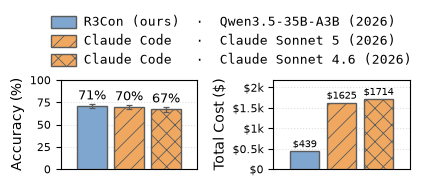

saved grounded_vs_claude.pdf


In [16]:
# Three focus runs — our method + Claude Code on TWO frontier models. Sourced from cq_real (NOT main:
# Claude Code isn't pinned into main anymore); each carries its underlying model, shown in the
# legend so the model-tier asymmetry is unmistakable. This figure is the deliberate scale contrast.
FIG_DIR = paths.FIGURES_DIR / "corpusqa"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DISPLAY = {"qwen3-5-35b-a3b": "Qwen3.5-35B-A3B",
                 "claude-sonnet-5": "Claude Sonnet 5", "claude-sonnet-4-6": "Claude Sonnet 4.6"}
# (method, model, label, hatch). R3Con is solid (""); the two Claude Code bars share the orange
# and differ ONLY by hatch — "//" for the newest Sonnet 5, "xx" for Sonnet 4.6 (CLAUDE_MODEL).
FOCUS = [(GROUNDED_METHOD, "qwen3-5-35b-a3b", f"{GROUNDED_NAME} (ours)", ""),
         ("claude-code", "claude-sonnet-5", "Claude Code", "//"),
         ("claude-code", CLAUDE_MODEL, "Claude Code", "xx")]
bars = []
for _meth, _model, _label, _hatch in FOCUS:
    sub = cq_real[(cq_real["method"] == _meth) & (cq_real["model"] == _model)]
    if _meth == GROUNDED_METHOD:                           # pin our method to its default (sr2/think)
        sub = sub[(sub["variant"] == "default") & (sub["summary_rounds"] == GROUNDED_SR)]
    _real, _allv, _, _ = report._scores(sub)              # accuracy with every failure counted wrong
    _p, _n = _allv.mean(), len(_allv)
    bars.append({
        "label": _label, "method": _meth, "model": _model, "hatch": _hatch, "acc": _p, "n": _n,
        "se": (_p * (1 - _p) / _n) ** 0.5,                # binomial standard error of the accuracy
        "usd": sub.loc[sub["status"] == "ok", "usd"].sum(),
    })

import matplotlib.patches as mpatches

# Bar fills come from the central registry (scoreboard.style — R3Con light blue / Claude Code light
# orange, shared by both Claude bars); soft grey outlines + per-bar hatches + error bars give the
# clean look. R3Con is solid (no stripes); the two Claude models differ only by hatch.
EDGE = "#5a5a5a"                                   # grey bar outline + hatch (hatch follows edge)
plt.rcParams["hatch.linewidth"] = 0.6             # thin hatch lines
_ERR = {"ecolor": "#5c5a5a", "elinewidth": 0.9, "capthick": 0.9}    # light grey, thin error bars

xs = list(range(len(bars)))
colors = [style.color(b["method"]) for b in bars]
hatches = [b["hatch"] for b in bars]
fig, (axA, axC) = plt.subplots(1, 2, figsize=(4.3, 1.5))   # a touch wider so 3 bars + $ labels don't crowd

# Left: accuracy as a PERCENTAGE (0–100); value labels like 71% / 67% on top of the bars.
accs = [b["acc"] * 100 for b in bars]
ses = [b["se"] * 100 for b in bars]
barsA = axA.bar(xs, accs, yerr=ses, capsize=2.5, color=colors, edgecolor=EDGE, linewidth=1.0,
                error_kw=_ERR, zorder=3)
for _rect, _h in zip(barsA, hatches):
    _rect.set_hatch(_h)
axA.set_ylabel("Accuracy (%)", fontsize=10)
axA.set_ylim(0, 100)
for x, a, s in zip(xs, accs, ses):
    axA.text(x, a + s + 1.5, f"{a:.0f}%", ha="center", va="bottom", fontsize=9.5)

# Right: total dollar cost.
_umax = max(b["usd"] for b in bars)
barsC = axC.bar(xs, [b["usd"] for b in bars], color=colors, edgecolor=EDGE, linewidth=1.0, zorder=3)
for _rect, _h in zip(barsC, hatches):
    _rect.set_hatch(_h)
axC.set_ylabel("Total Cost ($)", fontsize=10)
axC.set_ylim(0, _umax * 1.27)
axC.set_yticks([0, 500, 1000, 1500, 2000])
# y ticks $0 / $0.5k / $1k / $1.5k / $2k — local formatter (abbreviates from $0.5k up); the shared
# _kdollar (x-axes elsewhere, abbreviates from $1k) is left untouched.
axC.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v / 1000:g}k" if v >= 500 else f"${v:,.0f}"))
for x, b in zip(xs, bars):                                # in-bar $ labels stay full ($1,714 etc.)
    axC.text(x, b["usd"] + _umax * 0.02, f"${b['usd']:.0f}", ha="center", va="bottom", fontsize=7.5)

for ax in (axA, axC):
    ax.set_xticks([])
    ax.set_xlim(-0.85, len(bars) - 0.15)         # breathing room so bars don't hug the spines
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(True, axis="y", ls=":", alpha=0.4, zorder=0)
# Pad the method labels to equal width and render the legend in monospace, so the "·" and the model
# names after it line up in a column across the three rows (labels are padded to the longest one, so
# the models start at the same column whatever our method is called).
_lw = max(len(b["label"]) for b in bars)
handles = [mpatches.Patch(facecolor=style.color(b["method"]),
                          edgecolor=EDGE, hatch=b["hatch"],
                          label=f"{b['label']:<{_lw}}  ·  {MODEL_DISPLAY.get(b['model'], b['model'])} (2026)")
           for b in bars]
fig.tight_layout(w_pad=1.1)
fig.subplots_adjust(top=0.74)                     # extra headroom for the taller 3-row legend
fig.legend(handles=handles, loc="upper center", ncol=1, frameon=False,
           bbox_to_anchor=(0.55, 1.25), handlelength=2.0, handleheight=1.1,
           handletextpad=0.6, labelspacing=0.4, prop={"family": "monospace", "size": 9.0})
fig.savefig(FIG_DIR / "grounded_vs_claude.pdf", bbox_inches="tight")          # the paper's figure
fig.savefig(FIG_DIR / "grounded_vs_claude.png", dpi=300, bbox_inches="tight")  # local check render
display(fig)
plt.close(fig)
print("saved grounded_vs_claude.pdf")

# Cross-benchmark

## Ablations — the two phases

The method's **default** config (CodeAct, `summary_rounds = 2`, thinking) vs the two
**single-phase ablations** (all else equal), one column per benchmark — the paper's
`tab:ablation`. Each removes one phase of the pipeline; the downstream reasoner is untouched
(swapping *that* leaves the representation intact, so it is a separate comparison — see
**Downstream reasoning** below). Each cell is the total exact-match score (**Loong** = perfect
rate, fraction scoring 100; **CorpusQA** = accuracy, fraction correct) with the
**percentage-point change vs the default** in parentheses.

- **w/o extracting relevance** — `summary_rounds = 0`: no relevance state 𝓡 (Phase 1), so the
  extractor structures the raw documents. Same CodeAct downstream.
- **w/o structuring** — CodeAct re-run over 𝓡 with the structured parse (Phase 2) removed.

In [17]:
# Exact-match fraction per (ablation, benchmark) — over ALL tasks of each benchmark.
_abl = pd.DataFrame({
    "Loong":      report.ablations(loong).set_index("ablation")["em"],
    "CorpusQA":   report.ablations(cq).set_index("ablation")["em"],
})
_abl.index.name = "Ablation"


def _abl_text(v, base):                           # "37.50%" for the default; "25.12% (-12.36)" else
    if pd.isna(v):
        return "–"
    pct = f"{v * 100:.2f}%"
    return pct if v == base else f"{pct} ({(v - base) * 100:+.2f})"


# Colour each score by its band — Loong uses the perfect-rate bands, the 0/1 benchmarks the accuracy bands.
_abl_style = pd.DataFrame("", index=_abl.index, columns=_abl.columns)
_abl_style["Loong"] = _abl["Loong"].map(_band_em)
_abl_style["CorpusQA"] = _abl["CorpusQA"].map(_band_acc)
_abl_disp = pd.DataFrame(
    {c: [_abl_text(v, _abl[c].loc["Default"]) for v in _abl[c]] for c in _abl.columns},
    index=_abl.index)
display(_abl_disp.style.apply(lambda _: _abl_style, axis=None))

# LaTeX body rows for the paper's `tab:ablation`, in ITS column order (Loong, CorpusQA) and its
# row shapes: the default first, then each ablation indented with a `\loss{}` drop. This table
# keeps the trailing `\%` in the cell (unlike the other exports, whose templates add it).
_ABL_TEX = {"Default": r"\method{} (default) &",
            "w/o extracting relevance": r"\hspace{1em}w/o extracting relevance &",
            "w/o structuring": r"\hspace{1em}w/o structuring &"}
print("% --- tab:ablation body rows (Loong, CorpusQA) ---")
for _lbl, _pre in _ABL_TEX.items():
    _cells = []
    for _c in ("Loong", "CorpusQA"):
        _v, _base = _abl[_c].loc[_lbl], _abl[_c].loc["Default"]
        _cells.append("--" if pd.isna(_v) else
                      (rf"{_v * 100:.2f}\%" if _lbl == "Default"
                       else rf"{_v * 100:.2f}\%\loss{{{(_base - _v) * 100:.2f}}}"))
    print(f"{_pre} " + " & ".join(_cells) + r" \\")

,Loong,CorpusQA
Ablation,,
Default,37.43%,70.64%
w/o extracting relevance,23.96% (-13.47),52.58% (-18.06)
w/o structuring,32.97% (-4.46),63.22% (-7.42)


% --- tab:ablation body rows (Loong, CorpusQA) ---
\method{} (default) & 37.43\% & 70.64\% \\
\hspace{1em}w/o extracting relevance & 23.96\%\loss{13.47} & 52.58\%\loss{18.06} \\
\hspace{1em}w/o structuring & 32.97\%\loss{4.46} & 63.22\%\loss{7.42} \\


## Downstream reasoning

**Not an ablation** — both phases are intact and the *same* representation is handed to a
different downstream reasoner (the paper's `tab:downstream-reasoning`, appendix). The default
is the **coding agent**, which explores the structured data programmatically without holding it
all in context; the alternative is to hand the representation straight to the **LLM**.

Same scoping and scoring view as everything else (Loong tiers 2–4 exact-match rate, CorpusQA
`1m` accuracy, both ⁺all). Column order follows the paper's table: **CorpusQA, Loong**.

In [18]:
_dwn = pd.DataFrame({
    "CorpusQA": report.downstream(cq).set_index("downstream")["em"],
    "Loong":    report.downstream(loong).set_index("downstream")["em"],
})
_dwn.index.name = "Downstream reasoning"
_dwn_style = pd.DataFrame("", index=_dwn.index, columns=_dwn.columns)
_dwn_style["Loong"] = _dwn["Loong"].map(_band_em)
_dwn_style["CorpusQA"] = _dwn["CorpusQA"].map(_band_acc)
display(_dwn.style.apply(lambda _: _dwn_style, axis=None).format("{:.2%}", na_rep="–"))

# Neither paradigm dominates, so the per-column winner is bolded rather than ranked.
for _c in _dwn.columns:
    _w = _dwn[_c].idxmax()
    print(f"  {_c:9s} best = {_w} ({_dwn[_c].max() * 100:.2f}%), "
          f"margin {(_dwn[_c].max() - _dwn[_c].min()) * 100:+.2f} pp over "
          f"{_dwn[_c].idxmin()}")

# LaTeX body rows for `tab:downstream-reasoning` — the paper's column order (CorpusQA, Loong),
# its row labels, `\textbf{}` on each column's winner, `\%` kept in the cell as in that table.
_DWN_TEX = {"LLM": "LLM", "Coding agent (default)": "Coding Agent (default)"}
print("\n% --- tab:downstream-reasoning body rows (CorpusQA, Loong) ---")
for _lbl, _pre in _DWN_TEX.items():
    _cells = []
    for _c in ("CorpusQA", "Loong"):
        _v = _dwn[_c].loc[_lbl]
        _txt = "--" if pd.isna(_v) else rf"{_v * 100:.2f}\%"
        _cells.append(rf"\textbf{{{_txt}}}" if _v == _dwn[_c].max() else _txt)
    print(f"{_pre} & " + " & ".join(_cells) + r" \\")

,CorpusQA,Loong
Downstream reasoning,,
LLM,65.43%,40.17%
Coding agent (default),70.64%,37.43%


  CorpusQA  best = Coding agent (default) (70.64%), margin +5.21 pp over LLM
  Loong     best = LLM (40.17%), margin +2.74 pp over Coding agent (default)

% --- tab:downstream-reasoning body rows (CorpusQA, Loong) ---
LLM & 65.43\% & \textbf{40.17\%} \\
Coding Agent (default) & \textbf{70.64\%} & 37.43\% \\


## Totals (both benchmarks) — accuracy by category

Each method's **accuracy**, broken out by category, ⁺all view (prediction failures folded), same
served model (no Claude Code / direct-llm). Columns, left → right:

- **CorpusQA** — Education / Financial / Real-estate + **Overall** (0/1 accuracy).
- **Loong** — Paper / Financial / Legal + **Overall** (perfect / exact-match rate).

Our method last.

In [19]:
# Re-pin each benchmark's Main set (self-contained: same-model, no Claude Code / direct-llm), then
# read per-(method, category) accuracy in the ⁺all view via `report._se`. CorpusQA → 0/1
# accuracy (the S value); Loong → perfect / exact-match rate (EM). Joined by method; our method last.
def _main_pin(df):
    keep = (df["source"] == "baseline") & (~df["method"].isin(["claude-code", "direct-llm"])) & (df["variant"] == "default")
    keep |= (df["method"] == GROUNDED_METHOD) & (df["variant"] == "default") & (df["summary_rounds"] == GROUNDED_SR)
    return df[keep]

_lp, _cp = _main_pin(loong_real), _main_pin(cq_real)

# Display column -> raw `domain` value (same order as each section's by-domain board).
_CQ_DOMAINS = {"Education": "education", "Financial": "financial", "Real estate": "real estate"}
_LO_DOMAINS = {"Paper": "paper", "Financial": "financial", "Legal": "legal"}

# Column spec: (MultiIndex column, pinned df, domain value or None=Overall, se-index). se-index
# 0 = S (CorpusQA 0/1 accuracy); 1 = EM (Loong perfect / exact-match rate).
_spec = [(("CorpusQA", _d), _cp, _dom, 0) for _d, _dom in _CQ_DOMAINS.items()]
_spec += [(("CorpusQA", "Overall"), _cp, None, 0)]
_spec += [(("Loong", _d), _lp, _dom, 1) for _d, _dom in _LO_DOMAINS.items()]
_spec += [(("Loong", "Overall"), _lp, None, 1)]
_tcols = pd.MultiIndex.from_tuples([c for c, *_ in _spec])

_methods = [m for m in style.ORDER
            if any(m in set(p["method"]) for p in (_cp, _lp))]        # display order, method last
_tdata, _tidx = [], []
for _m in _methods:
    _row = {}
    for _col, _pin, _dom, _si in _spec:
        _g = _pin[_pin["method"] == _m]
        if _dom is not None:
            _g = _g[_g["domain"] == _dom]
        _row[_col] = report._se(_g)[_si] if len(_g) else float("nan")
    _tdata.append(_row); _tidx.append(style.name(_m))
totals = pd.DataFrame(_tdata, index=_tidx, columns=_tcols).rename_axis("method")


def _totals_style(df):
    # Loong cells use the perfect-rate bands (_band_em); CorpusQA the accuracy bands.
    s = pd.DataFrame("", index=df.index, columns=df.columns)
    for _col in df.columns:
        s[_col] = df[_col].map(_band_em if _col[0] == "Loong" else _band_acc)
    return s


totals.style.apply(_totals_style, axis=None).format("{:.2%}", na_rep="–")

### LaTeX — Totals rows (by category)

The **internal rows** of the by-category Totals table above, from `\midrule` — ready to copy-paste,
columns in the SAME order (CorpusQA Education/Financial/Real-estate/Overall · Loong
Paper/Financial/Legal/Overall). One row per method (`LATEX_PREAMBLE` order);
each cell a bare 2-decimal accuracy value, no `\%` (Loong = perfect / exact-match rate); the per-column max wrapped
in `\best{}`; a missing method/category `--`. Reuses `_spec`, so it stays in lockstep with the table.

In [20]:
def latex_totals_rows():
    r"""The by-category Totals table as LaTeX body rows — same columns/order as ``_spec`` (CorpusQA
    Ed/Fin/RE/Overall · Loong Paper/Fin/Legal/Overall), one row per method
    (``LATEX_PREAMBLE`` order). Each cell a bare 2-decimal accuracy value, no ``\%`` (Loong = perfect /
    exact-match rate); the per-column max wrapped in ``\best{}``; a missing method/category ``--``."""
    def _acc(pin, m, dom, si):                             # per-(method, category) accuracy %, as the table
        g = pin[pin["method"] == m]
        if dom is not None:
            g = g[g["domain"] == dom]
        return report._se(g)[si] * 100 if len(g) else float("nan")

    _cols = [(pin, dom, si) for _c, pin, dom, si in _spec]        # (pinned df, domain|None, S/EM) per column
    _vals = {m: [_acc(pin, m, dom, si) for pin, dom, si in _cols] for m in LATEX_PREAMBLE}
    _colmax = [max((_vals[m][j] for m in LATEX_PREAMBLE if _vals[m][j] == _vals[m][j]), default=float("nan"))
               for j in range(len(_cols))]

    def _cell(v, b):                                       # \best on the column max; `--` when missing
        if v != v:
            return "--"
        return rf"\best{{{v:.2f}}}" if v == b else f"{v:.2f}"

    rows = [f"{pre} " + " & ".join(_cell(v, _colmax[j]) for j, v in enumerate(_vals[m])) + r" \\"
            for m, pre in LATEX_PREAMBLE.items()]
    return "\\midrule\n" + "\n%\n".join(rows)


print(latex_totals_rows())

\midrule
RAPTOR~\citeyearpar{DBLP:conf/iclr/SarthiATKGM24} & 8.00 & 11.11 & 17.95 & 12.06 & 0.00 & 22.17 & 5.71 & 12.12 \\
%
ReadAgent~\citeyearpar{DBLP:conf/icml/LeeCFCF24} & 42.68 & 37.42 & 31.25 & 37.23 & 15.15 & 35.33 & 14.93 & 24.49 \\
%
MemAgent~\citeyearpar{yu2026memagent} & 7.32 & 7.83 & 8.64 & 7.90 & 0.00 & 26.80 & 4.00 & 13.63 \\
%
HippoRAG2~\citeyearpar{DBLP:conf/icml/GutierrezSQZ025} & 7.32 & 7.83 & 20.99 & 10.94 & 0.32 & 17.42 & 6.29 & 10.06 \\
%
LinearRAG~\citeyearpar{zhuang2026linearrag} & 8.54 & 6.63 & 16.05 & 9.42 & 0.61 & 9.38 & 5.43 & 6.04 \\
%
StructRAG~\citeyearpar{DBLP:conf/iclr/LiC0L0T0H0L25} & 53.66 & 55.42 & 38.27 & 50.76 & 19.70 & 32.66 & 12.32 & 23.72 \\
%
CodeAgent~\citeyearpar{smolagents} & 14.63 & 26.99 & 26.25 & 23.69 & 13.80 & 40.07 & 24.26 & 29.01 \\
%
RLMs~\citeyearpar{DBLP:journals/corr/abs-2512-24601} & 13.41 & 37.58 & 20.51 & 27.38 & 12.77 & 41.67 & 22.77 & 28.96 \\
%
A-RAG~\citeyearpar{DBLP:journals/corr/abs-2602-03442} & 8.54 & 7.23 & 18.52 & 10.3

### Overall accuracy + our margin (plain print)

The **Overall** ⁺all accuracy per benchmark (CorpusQA · Loong) and **our method's
margin over the best baseline** — printed plainly (no LaTeX). Reuses the pinned frames
(`_cp` / `_lp`) from the Totals cell above.

In [21]:
_ov_bench = [("CorpusQA", _cp, 0), ("Loong", _lp, 1)]   # (label, pinned df, se-index)

def _ov_acc(pin, m, si):
    g = pin[pin["method"] == m]
    return report._se(g)[si] if len(g) else float("nan")

print(f"Overall accuracy (⁺all) — {GROUNDED_NAME} vs. the best baseline:\n")
for _name, _pin, _si in _ov_bench:
    _ours = _ov_acc(_pin, GROUNDED_METHOD, _si)
    _others = {m: _ov_acc(_pin, m, _si) for m in _pin["method"].unique() if m != GROUNDED_METHOD}
    _others = {m: v for m, v in _others.items() if v == v}         # drop NaNs
    _bm, _bv = max(_others.items(), key=lambda kv: kv[1])          # best other (baseline) method
    _d = (_ours - _bv) * 100                                       # our margin in percentage points
    _verb = "gain" if _d >= 0 else "loss"
    print(f"  {_name:11s} {GROUNDED_NAME} {_ours * 100:6.2f}%   vs best baseline {style.name(_bm)} "
          f"{_bv * 100:.2f}%   -> {_verb} {abs(_d):.2f} pp")

Overall accuracy (⁺all) — R3Con vs. the best baseline:

  CorpusQA    R3Con  70.64%   vs best baseline StructRAG 50.76%   -> gain 19.88 pp
  Loong       R3Con  37.43%   vs best baseline CodeAgent 29.01%   -> gain 8.42 pp


## Total cost

Quality vs. **total** dollar cost on each benchmark, as **two side-by-side panels** (one point per
pinned method, log-x with compact `$` ticks and its own "Total Cost ($)" label; colour/marker
from `scoreboard.style`) — every baseline on the **same served model** (no Claude Code):

- **CorpusQA** (left) — *Accuracy* (%, every failure counted wrong).
- **Loong** (right) — *Accuracy* (%, the perfect / exact-match rate).

A dashed grey line traces each panel's **cost/quality Pareto frontier** — the non-dominated points,
i.e. every method that no other method beats on BOTH price and accuracy. Anything below the line is
dominated. **R3Con is the frontier's top-right endpoint on both benchmarks** (nothing reaches its
accuracy at any price) — and it is *not* the priciest point: ReadAgent and HippoRAG2 sit further
right on both panels while scoring a third of it.

Both panels plot **Accuracy (%)**, so they share **one y-label** (`fig.supylabel`); each sets its own
cost x-range.

The plot also carries **our default config run with the WHOLE pipeline on the smaller `Qwen3.5-9B`
and `Qwen3.5-4B`** — our marker and colour, **9B bigger than 4B** and both smaller than 35B, in
their own legend box. (The twin figure without those two points was removed — owner, 2026-09-21;
it was a strict subset of this one and the paper never included it.)

- **The Pareto frontier is recomputed over every plotted point**, the smaller sizes included — a
  frontier that ignored plotted points could leave one sitting above the line.
- **Prices** (`scoreboard.load.PRICE`, USD per 1M in/out) put all three Qwen sizes on ONE provider's
  endpoint so the size comparison isn't a provider/quantization mix: 35B-A3B $0.14/$1.00 and 9B
  $0.10/$0.15 are DeepInfra on openrouter.ai; 4B isn't listed there, so its $0.05/$0.07 is
  owner-supplied.

These sizes are **not** in any other table or figure (the benchmark sections assert 35B-only).
Written to `<figures_dir>/cross/cost_cross_sizes.pdf`.

In [22]:
from matplotlib.lines import Line2D

FIG_DIR = paths.FIGURES_DIR / "cross"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Re-pin both benchmarks here so the cell is self-contained (`main` / `pin_main` were reassigned
# per section). Reads the stable per-inference tables + the shared-config constants up top.
# Both: baselines + R3Con, same served model — NO Claude Code (different model, shown elsewhere).
loong_pin = loong_real[
    ((loong_real["source"] == "baseline") & (~loong_real["method"].isin(["claude-code", "direct-llm"])) & (loong_real["variant"] == "default"))
    | ((loong_real["method"] == GROUNDED_METHOD) & (loong_real["variant"] == "default") & (loong_real["summary_rounds"] == GROUNDED_SR))
]
cq_pin = cq_real[
    ((cq_real["source"] == "baseline") & (cq_real["method"] != "claude-code") & (cq_real["variant"] == "default"))
    | ((cq_real["method"] == GROUNDED_METHOD) & (cq_real["variant"] == "default") & (cq_real["summary_rounds"] == GROUNDED_SR))
]
loong_cost = report.cost_table(loong_pin)
loong_cost = loong_cost[loong_cost["usd_total"].notna()]
cq_cost = report.cost_table(cq_pin)
cq_cost = cq_cost[cq_cost["usd_total"].notna()]


# The frontier line's style, in ONE place — the panel line and the legend swatch both read it, so
# they can never drift apart.
_PARETO_KW = dict(ls="--", lw=1.1, color="#7a7a7a", alpha=0.75)

# Our method is the figure's focal point, so it gets a BIGGER marker on the panels and a matching
# bigger swatch in its legend box. `_OURS_SCALE` is the linear size factor and drives both: matplotlib's
# scatter `s` is an AREA (pt²) so it squares, while a legend handle's `markersize` is a length (pt)
# so it multiplies directly — that keeps the swatch the same visual size as the point it stands for.
# Draw order on the cost panels: frontier line (2) < OUR markers (2.5) < every other method (3). Ours
# are the biggest, so putting them underneath keeps an overlapped baseline fully readable while ours
# still shows all round. Swap these two to put ours back on top.
_Z_OURS, _Z_BASE = 2.5, 3
_MARK_S = 80          # scatter marker area (pt²) for every baseline
_LEG_MS = 8           # legend swatch marker size (pt) for every baseline (≈ sqrt(_MARK_S))
_OURS_LEG_MS = 15     # our method's size IN POINTS — bump this by 1 to grow it by a point
_OURS_SCALE = _OURS_LEG_MS / _LEG_MS   # the same linear factor, applied to the panel marker


def _pareto_front(xs, ys):
    """The non-dominated (cheap, accurate) points: walking cheapest→dearest, keep every point that
    beats ALL cheaper ones on accuracy. Anything below the resulting line is dominated — some other
    method is both cheaper AND better."""
    front, best = [], float("-inf")
    for x, y in sorted(zip(xs, ys)):
        if y > best:
            front.append((x, y))
            best = y
    return front


def _cost_panel(ax, cost, col, yfn, title, xticks, xlim, show_xlabel, extra=None):
    """One cost/quality panel. ``extra`` (optional) = additional points of OUR method on other Qwen
    sizes — a frame with ``usd_total``, ``col``, ``_s`` (marker area, pt²) and ``label`` — drawn with our
    marker/colour at their own size. They join the x-limit guard, the Pareto frontier and the y-range,
    so no plotted point can sit above the frontier line. ``extra=None`` draws the panel without them."""
    _extra = extra if extra is not None else pd.DataFrame(columns=["usd_total", col, "_s", "label"])
    # Guard: a method whose cost falls outside xlim would be silently clipped off the panel (this
    # bit us when HippoRAG2 landed at $72 on a panel whose limit was $60). Shout instead of hiding.
    _out = cost[(cost["usd_total"] < xlim[0]) | (cost["usd_total"] > xlim[1])]
    _out_x = _extra[(_extra["usd_total"] < xlim[0]) | (_extra["usd_total"] > xlim[1])]
    if len(_out) or len(_out_x):
        print(f"  !! {title}: {list(_out['method']) + list(_out_x['label'])} outside x-limits {xlim} — widen them")
    # Cost/quality Pareto frontier, drawn UNDER the markers so it guides the eye without competing.
    _front = _pareto_front([*cost["usd_total"], *_extra["usd_total"]],
                           [*cost[col].map(yfn), *_extra[col].map(yfn)])
    if len(_front) > 1:
        ax.plot([p[0] for p in _front], [p[1] for p in _front], zorder=2, **_PARETO_KW)
    # Ours are the BIGGEST markers, so they are drawn UNDERNEATH every other method (_Z_OURS < _Z_BASE):
    # where points overlap, the other method stays fully visible and ours still reads, because it sticks
    # out all round. Drawn above the frontier line (zorder 2) so the dashes don't cross our markers.
    for _, r in _extra.iterrows():                        # our other sizes: same marker, own (smaller) size
        ax.scatter(r["usd_total"], yfn(r[col]), s=r["_s"], edgecolor="black", linewidth=0.4,
                   color=style.GROUNDED_COLOR, marker=style.marker(GROUNDED_METHOD), zorder=_Z_OURS)
    for _, r in cost.iterrows():
        _is_ours = r["method"].startswith("grounded")     # bigger marker, drawn UNDER the rest
        ax.scatter(r["usd_total"], yfn(r[col]),
                   s=_MARK_S * (_OURS_SCALE ** 2 if _is_ours else 1),
                   edgecolor="black", linewidth=0.4,
                   color=style.color(r["method"]), marker=style.marker(r["method"]),
                   zorder=_Z_OURS if _is_ours else _Z_BASE)
    ys = cost[col].map(yfn)                               # Loong: EM (perfect rate); CorpusQA: S (accuracy)
    if len(_extra):
        ys = pd.concat([ys, _extra[col].astype(float).map(yfn)], ignore_index=True)
    ax.set_xscale("log")
    ax.set_xlim(*xlim)                                    # same range on both panels (aligned)
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(FuncFormatter(_kdollar))  # compact $ ticks ($1k / $2k)
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_ylim(max(0, ys.min() - 10), ys.max() + 13.5)
    ax.set_title(title, fontsize=11)                      # y-label is shared (fig.supylabel) — not per panel
    if show_xlabel:                                       # the "Total Cost ($)" text appears once...
        ax.set_xlabel("Total Cost ($)", fontsize=11)
    ax.tick_params(labelsize=9.5)
    ax.grid(True, which="major", ls=":", alpha=0.4)


# Legend entries for the figure below: the nine baselines in display order (our method gets its own
# box, built inline). `present` is what actually reached a panel, so a method absent from both
# never reaches the legend either.
present = set(loong_cost["method"]) | set(cq_cost["method"])
order = [m for m in style.ORDER if m in present]


def _handle(m, size=_LEG_MS):
    return Line2D([], [], marker=style.marker(m), markerfacecolor=style.color(m), markeredgecolor="black",
                  markeredgewidth=0.4, markersize=size, linestyle="None")


_base = [m for m in order if not m.startswith("grounded")]

Loong     R3Con (9B)     acc= 33.54%  total=$87.30
Loong     R3Con (4B)     acc= 30.23%  total=$42.76
CorpusQA  R3Con (9B)     acc= 54.88%  total=$173.90
CorpusQA  R3Con (4B)     acc= 49.24%  total=$81.94


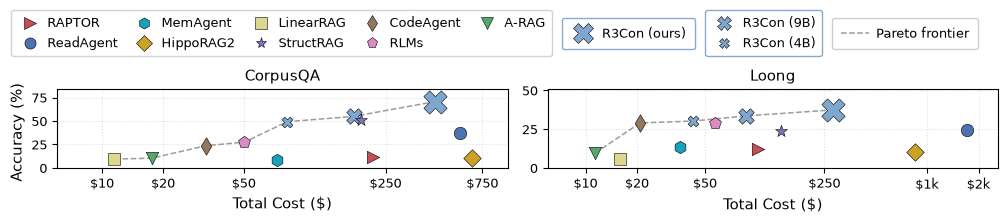

saved cost_cross_sizes.pdf


In [23]:
# (model, legend label, legend marker size in pt). 35B is _OURS_LEG_MS; each smaller size is smaller.
_SIZES = [("qwen3-5-9b", f"{GROUNDED_NAME} (9B)", 10), ("qwen3-5-4b", f"{GROUNDED_NAME} (4B)", 7)]

def _size_points(df, col):
    """Our default config on each smaller size, as `_cost_panel` `extra` points. `df` is the section's
    scoped per-inference frame (`loong` / `cq`) — NOT `*_real`, which KEEP_MODELS has stripped of these."""
    rows = []
    for model, label, pt in _SIZES:
        g = df[(df["source"] == "method") & (df["method"] == GROUNDED_METHOD) & (df["variant"] == "default")
               & (df["summary_rounds"] == GROUNDED_SR) & (df["model"] == model)]
        c = report.cost_table(g).iloc[0]
        rows.append({"usd_total": c["usd_total"], col: c[col], "label": label,
                     "_s": _MARK_S * (pt / _LEG_MS) ** 2})   # legend pt -> panel area, same rule as ours
    return pd.DataFrame(rows)


loong_sizes = _size_points(loong, "EM")
cq_sizes = _size_points(cq, "S")
for _b, _t, _col in (("Loong", loong_sizes, "EM"), ("CorpusQA", cq_sizes, "S")):
    for _, r in _t.iterrows():
        print(f"{_b:9s} {r['label']:14s} acc={100 * r[_col]:6.2f}%  total=${r['usd_total']:,.2f}")

fig, (axC, axL) = plt.subplots(1, 2, figsize=(10.45, 1.74))   # 10.45 wide so four legend boxes fit
_cost_panel(axL, loong_cost, "EM", lambda s: s * 100, "Loong",    [10, 20, 50, 250, 1000, 2000], (6, 2600), show_xlabel=True, extra=loong_sizes)
_cost_panel(axC, cq_cost,    "S",  lambda s: s * 100, "CorpusQA", [10, 20, 50, 250, 750],        (6, 1000), show_xlabel=True, extra=cq_sizes)
fig.supylabel("Accuracy (%)", fontsize=11, x=0.04, y=0.55)
axL.set_yticks([0, 25, 50])
axC.set_yticks([0, 25, 50, 75])

fig.tight_layout()
fig.subplots_adjust(left=0.085)
# FOUR legend boxes don't fit hand-set anchors (they collided), so
# each box is placed just right of the previous one's MEASURED edge — overlap is impossible by
# construction. `_LEG_GAP` (figure fraction) is the one spacing knob.
_LEG_GAP = 0.004
_rend = fig.canvas.get_renderer()
_right = lambda leg: leg.get_window_extent(_rend).transformed(fig.transFigure.inverted()).x1   # right edge, fig coords
# The baselines block, then our 35B marker…
_lb = fig.legend([_handle(m) for m in _base], [style.name(m) for m in _base],
                 loc="lower left", bbox_to_anchor=(0.035, 0.95), ncol=5, fontsize=9,
                 frameon=True, framealpha=0.9, handletextpad=0.4, columnspacing=1.1,
                 labelspacing=0.5, borderpad=0.5)
_lo = fig.legend([_handle(GROUNDED_METHOD, size=_LEG_MS * _OURS_SCALE)], [f"{GROUNDED_NAME} (ours)"],
                 loc="lower left", bbox_to_anchor=(_right(_lb) + _LEG_GAP, 0.99), ncol=1, fontsize=9,
                 frameon=True, framealpha=0.95, handletextpad=0.5, borderpad=0.7, edgecolor=style.GROUNDED_COLOR)
# …plus a box for our smaller sizes: same marker + colour, smaller swatches (9B > 4B), same brand frame.
_ls = fig.legend([_handle(GROUNDED_METHOD, size=pt) for _, _, pt in _SIZES], [lbl for _, lbl, _ in _SIZES],
                 loc="lower left", bbox_to_anchor=(_right(_lo) + _LEG_GAP, 0.95), ncol=1, fontsize=9,
                 frameon=True, framealpha=0.95, handletextpad=0.5, labelspacing=0.5, borderpad=0.5,
                 edgecolor=style.GROUNDED_COLOR)
fig.legend([Line2D([], [], **_PARETO_KW)], ["Pareto frontier"],
           loc="lower left", bbox_to_anchor=(_right(_ls) + _LEG_GAP, 0.99), ncol=1, fontsize=9,
           frameon=True, framealpha=0.95, handletextpad=0.6, borderpad=0.7, handlelength=2.2)
fig.savefig(FIG_DIR / "cost_cross_sizes.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "cost_cross_sizes.png", dpi=300, bbox_inches="tight")
display(fig)
plt.close(fig)
print("saved cost_cross_sizes.pdf")

## Model sizes — R3Con vs StructRAG vs CodeAgent (LaTeX)

The same three methods with **the whole pipeline on one model size** — Qwen3.5-35B-A3B (the comparison model
everywhere else), 9B and 4B — as copy-paste LaTeX body rows: one `\threecolgrey{\texttt{<model>}}` block per size,
rows **StructRAG, CodeAgent, ours**, columns **CorpusQA** (`1m` accuracy) then **Loong** (tiers 2–4 exact-match
rate), both ⁺all (every error / step-cap counted wrong), bare 2-decimal values (no `\%`). **`\best{}` marks the column max WITHIN each
size block**; a missing run prints `--`. Our method is its default config (CodeAct, `summary_rounds = 2`, thinking).

- **This is the ONLY place the baselines' 4B / 9B runs appear** (owner). Every other board and figure is 35B-only,
  enforced by `KEEP_MODELS` + the size asserts at the top of each benchmark section.

In [24]:
_SIZE_MODELS = [("qwen3-5-35b-a3b", "Qwen3.5-35B-A3B"), ("qwen3-5-9b", "Qwen3.5-9B"), ("qwen3-5-4b", "Qwen3.5-4B")]
_SIZE_METHODS = ["structrag", "codeact", GROUNDED_METHOD]          # row order; preambles from LATEX_PREAMBLE
# `cq` / `loong` are the scoped frames with ALL models (the *_real frames are 35B-only by design). `cq` already
# keeps only CodeAgent's max_steps=60 config, which is what every CorpusQA size ran.
_SIZE_BENCH = [("CorpusQA", cq, "S"), ("Loong", loong, "EM")]    # column order


def _size_acc(model, meth, df, col):
    """Accuracy (%) of one method on one model size, or None if it has no run."""
    g = df[(df["method"] == meth) & (df["model"] == model) & (df["variant"] == "default")]
    if meth == GROUNDED_METHOD:
        g = g[g["summary_rounds"] == GROUNDED_SR]
    return report.cost_table(g).iloc[0][col] * 100 if len(g) else None


_blocks = []
for _model, _label in _SIZE_MODELS:
    _vals = {m: [_size_acc(_model, m, df, col) for _, df, col in _SIZE_BENCH] for m in _SIZE_METHODS}
    _colmax = [max(v[j] for v in _vals.values() if v[j] is not None) for j in range(len(_SIZE_BENCH))]
    _rows = []
    for _m in _SIZE_METHODS:
        _cells = []
        for _j, _v in enumerate(_vals[_m]):
            if _v is None:
                _cells.append("--")
            else:
                _txt = f"{_v:.2f}"
                _cells.append(rf"\best{{{_txt}}}" if _v == _colmax[_j] else _txt)
        _rows.append(f"{LATEX_PREAMBLE[_m]} " + " & ".join(_cells) + r" \\")
    _blocks.append(rf"\threecolgrey{{\texttt{{{_label}}}}}" + "\n\\midrule\n" + "\n".join(_rows))

print("\n\\midrule\n".join(_blocks))

\threecolgrey{\texttt{Qwen3.5-35B-A3B}}
\midrule
StructRAG~\citeyearpar{DBLP:conf/iclr/LiC0L0T0H0L25} & 50.76 & 23.72 \\
CodeAgent~\citeyearpar{smolagents} & 23.69 & 29.01 \\
\method{} (ours) & \best{70.64} & \best{37.43} \\
\midrule
\threecolgrey{\texttt{Qwen3.5-9B}}
\midrule
StructRAG~\citeyearpar{DBLP:conf/iclr/LiC0L0T0H0L25} & 40.43 & 20.30 \\
CodeAgent~\citeyearpar{smolagents} & 20.13 & 22.23 \\
\method{} (ours) & \best{54.88} & \best{33.54} \\
\midrule
\threecolgrey{\texttt{Qwen3.5-4B}}
\midrule
StructRAG~\citeyearpar{DBLP:conf/iclr/LiC0L0T0H0L25} & 29.79 & 16.84 \\
CodeAgent~\citeyearpar{smolagents} & 10.92 & 19.44 \\
\method{} (ours) & \best{49.24} & \best{30.23} \\


# Method internals — how much do we compress?

**Our method only, default config** (CodeAct / `summary_rounds = 2` / thinking / Qwen) — how big the
just-in-time artifacts are next to the task's input documents:

- **Input** — the task's documents (the external context), `input_tokens` from the vendored
  `scoreboard/data/*_meta.json` snapshots.
- **Summaries** — the **final** round's per-doc summaries, concatenated (`rounds[-1]`).
- **Parse** — the extractor's merged structured object (`parsed`), as JSON with `indent=2` (non-ASCII
  kept) — exactly how the method serializes it for the inference prompt. This is "the
  structured stuff we end up with" — what the code agent actually computes over.
- **Schema** — the proposer's generated Pydantic `schema_code` (small, shown for completeness).

**Every token count is EXACT and in ONE tokenizer** — the **served model's own**
(`Qwen/Qwen3.5-35B-A3B`, via `scoreboard.load.count_tokens_batch`), so each "% of input" is a like-for-like ratio.
The artifacts are tokenized here; the **input** documents' text stays upstream, so the snapshot
scripts rebuild each task's documents the way the method read them (verified to reproduce every run
manifest's `context_chars` to the character: Loong 1600/1600, CorpusQA 329/329) and vendor their
Qwen token count. Two things this replaced: a chars-per-token estimate for CorpusQA that was off by
−49% to +68% per corpus, and Loong's own `length` field, which is a *different* tokenizer (Qwen
counts run a median 0.85× of it).

Task scoping matches the rest of the notebook: Loong tiers 2–4, CorpusQA `1m`.

In [25]:
# One row per RUN folder (summaries/proposer/extractor are shared by a run's strategies), pinned to
# our default config, scoped to the same tasks as the benchmark sections above.
art = load.load_method_artifacts()
art = art[(art["variant"] == "default") & (art["summary_rounds"] == GROUNDED_SR)
          & (art["model"] == report.PRIMARY_MODEL)].copy()

_lm, _cm = meta.loong_meta(), meta.corpusqa_meta()
art["set"] = [(_lm.get(t, {}).get("set") if b == "loong" else _cm.get(t, {}).get("set"))
              for b, t in zip(art["benchmark"], art["task_id"])]
art["task"] = art["task_id"].astype("string").str.extract(r"@(task\d+)$", expand=False)
art = art[((art["benchmark"] == "loong") & (art["set"] != 1))              # tiers 2–4 (set 1 excluded)
          | ((art["benchmark"] == "corpusqa") & (art["set"] == "1m"))]


# Exact Qwen token count of each task's documents, from the vendored snapshot (see the note above).
art["input_tokens"] = [float((_lm if b == "loong" else _cm)[t]["input_tokens"])
                       for b, t in zip(art["benchmark"], art["task_id"])]
print("runs (default config):", art.groupby("benchmark").size().to_dict())

runs (default config): {'corpusqa': 329, 'loong': 1277}


### Compression per benchmark

`% of input` = artifact ÷ input; `compression` = input ÷ artifact (both at the corpus level, i.e.
mean over tasks). The **per-task median** compression is shown alongside, since means are pulled by
the biggest tasks.

In [26]:
_BENCH_ORDER = ["loong", "corpusqa"]
_BENCH_LABEL = {"loong": "Loong", "corpusqa": "CorpusQA"}

_rows, _idx = [], []
for _b in [b for b in _BENCH_ORDER if b in set(art["benchmark"])]:
    _g = art[art["benchmark"] == _b]
    _in = _g["input_tokens"].mean()
    _row = {("", "n"): len(_g), ("Input", "tokens"): _in}
    for _label, _col in [("Summaries", "summary_tokens"), ("Parse", "parse_tokens")]:
        _a = _g[_col].mean()
        _row[(_label, "tokens")] = _a
        _row[(_label, "% of input")] = _a / _in if _in else float("nan")
        _row[(_label, "compression")] = _in / _a if _a else float("nan")
        _row[(_label, "median ×")] = (_g["input_tokens"] / _g[_col].replace(0, float("nan"))).median()
    _row[("Schema", "tokens")] = _g["schema_tokens"].mean()
    _rows.append(_row); _idx.append(_BENCH_LABEL[_b])
compress = pd.DataFrame(_rows, index=_idx).rename_axis("benchmark")

_fmt = {c: ("{:,.0f}" if c[1] in ("tokens", "n") else ("{:.2%}" if c[1] == "% of input" else "{:.1f}×"))
        for c in compress.columns}
compress.style.format(_fmt, na_rep="–").map(
    lambda v: "color: #1a7f37; font-weight: 600",
    subset=[c for c in compress.columns if c[1] in ("compression", "median ×")])

,"('', 'n')","('Input', 'tokens')","('Summaries', 'tokens')","('Summaries', '% of input')","('Summaries', 'compression')","('Summaries', 'median ×')","('Parse', 'tokens')","('Parse', '% of input')","('Parse', 'compression')","('Parse', 'median ×')","('Schema', 'tokens')"
benchmark,,,,,,,,,,,
Loong,"1,277","103,541","1,344",1.30%,77.0×,101.0×,"1,179",1.14%,87.8×,185.1×,175
CorpusQA,329,"899,942","7,454",0.83%,120.7×,147.0×,"12,427",1.38%,72.4×,210.5×,198


### Paper table — `tab:intermediate-representation-size` (token counts + % of the external context)

The paper's table, in its column order (**CorpusQA, Loong**). Each benchmark's **average per task**,
in exact Qwen tokens: the external context itself, the relevance state $\mathcal{R}$ (the final-round
summaries) and the structured data (the parse). `% of context` = average component ÷ average context
(the same ratio-of-means as the table above). **Loong = the three kept tiers only (sets 2–4)**, like
everywhere in this notebook; CorpusQA = `1m`. The LaTeX below prints both the percentage rows (as in the
paper) and the average-token rows, with the paper's row labels.

In [27]:
_PAPER_BENCH = [("corpusqa", "CorpusQA"), ("loong", "Loong")]              # the paper's column order
_PAPER_ROWS = [  # (display name, LaTeX row label, artifact column — None = the context itself)
    ("External context", r"External context", None),
    ("Relevance state R", r"Relevance state $\mathcal{R}$ (after Phase 1 in Fig.~\ref{fig:r3agent})", "summary_tokens"),
    ("Structured data", r"Structured data (after Phase 2 in Fig.~\ref{fig:r3agent})", "parse_tokens"),
]
_avg = {b: art.loc[art["benchmark"] == b, ["input_tokens", "summary_tokens", "parse_tokens"]].mean()
        for b, _ in _PAPER_BENCH}
ir_size = pd.DataFrame(
    {(lbl, k): [(_avg[b]["input_tokens"] if col is None else _avg[b][col]) if k == "avg tokens"
                else (1.0 if col is None else _avg[b][col] / _avg[b]["input_tokens"]) for _, _, col in _PAPER_ROWS]
     for b, lbl in _PAPER_BENCH for k in ("avg tokens", "% of context")},
    index=[name for name, _, _ in _PAPER_ROWS]).rename_axis("representation")
display(ir_size.style.format({c: ("{:,.0f}" if c[1] == "avg tokens" else "{:.2%}") for c in ir_size.columns}))

print("% --- size as a % of the external context (as in tab:intermediate-representation-size) ---")
for _, tex, col in _PAPER_ROWS[1:]:
    print(f"{tex} & " + " & ".join(f"{_avg[b][col] / _avg[b]['input_tokens'] * 100:.2f}" for b, _ in _PAPER_BENCH) + r" \\")
print("% --- average tokens per task (exact, Qwen3.5 tokenizer; Loong = sets 2-4) ---")
for _, tex, col in _PAPER_ROWS:
    print(f"{tex} & " + " & ".join(f"{_avg[b]['input_tokens' if col is None else col]:,.0f}".replace(",", "{,}")
                                   for b, _ in _PAPER_BENCH) + r" \\")

% --- size as a % of the external context (as in tab:intermediate-representation-size) ---
Relevance state $\mathcal{R}$ (after Phase 1 in Fig.~\ref{fig:r3agent}) & 0.83 & 1.30 \\
Structured data (after Phase 2 in Fig.~\ref{fig:r3agent}) & 1.38 & 1.14 \\
% --- average tokens per task (exact, Qwen3.5 tokenizer; Loong = sets 2-4) ---
External context & 899{,}942 & 103{,}541 \\
Relevance state $\mathcal{R}$ (after Phase 1 in Fig.~\ref{fig:r3agent}) & 7{,}454 & 1{,}344 \\
Structured data (after Phase 2 in Fig.~\ref{fig:r3agent}) & 12{,}427 & 1{,}179 \\


### Token distributions — relevance state and structured data, per example

The per-example spread behind the averages in the paper table: one panel per representation component,
one histogram per benchmark, on the **served Qwen3.5-35B-A3B** default config (Loong = sets 2–4, CorpusQA =
`1m`). Token counts are exact (same tokenizer as the table; the parse as the method's own `indent=2` JSON).
The y-axis is **% of that benchmark's examples**, so Loong (1,277) and CorpusQA (329) are comparable despite
the 4× difference in count. Both panels share one log-spaced token axis and the same bins, so their
positions compare directly; dashed lines are each benchmark's median. The one CorpusQA run with no parse
is left out of the structured-data panel (a log axis can't show 0).
Written to `<figures_dir>/cross/ir_tokens.pdf`.

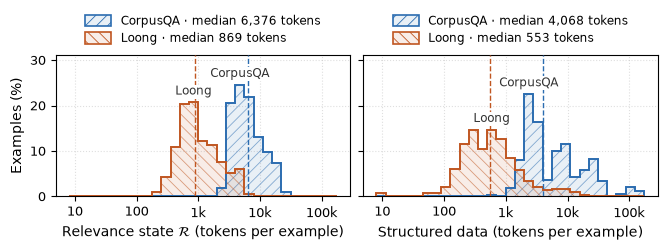

In [28]:
FIG_DIR = paths.FIGURES_DIR / "cross"
FIG_DIR.mkdir(parents=True, exist_ok=True)

_IR_BENCH = [("CorpusQA", "corpusqa"), ("Loong", "loong")]   # CorpusQA first, like the other figures
_IR_PANELS = [(r"Relevance state $\mathcal{R}$ (tokens per example)", "summary_tokens"),
              ("Structured data (tokens per example)", "parse_tokens")]
_IR_INK = "#333333"                                           # text stays neutral ink, never the series colour

_vals = {(b, col): art.loc[(art["benchmark"] == b) & (art[col] > 0), col] for _, b in _IR_BENCH for _, col in _IR_PANELS}
_lo = min(v.min() for v in _vals.values()); _hi = max(v.max() for v in _vals.values())
_ir_bins = np.logspace(np.log10(_lo) - 0.05, np.log10(_hi) + 0.05, 30)   # ONE set of bins for every histogram

from matplotlib.colors import to_rgba
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.6), sharex=True, sharey=True)
for ax, (xlabel, col) in zip(axes, _IR_PANELS):
    handles = []
    for label, b in _IR_BENCH:
        v, color, hatch = _vals[(b, col)], BENCH_COLOR[label], BENCH_HATCH[label]
        w = np.full(len(v), 100 / len(v))                     # % of THIS benchmark's examples
        # Fill = a light tint + the benchmark's HATCH (drawn in the edge colour; lw=0 so only the hatch shows —
        # the solid outline comes from the step line on top). Identity no longer rests on colour alone.
        ax.hist(v, bins=_ir_bins, weights=w, histtype="stepfilled", facecolor=to_rgba(color, 0.10),
                edgecolor=to_rgba(color, 0.55), hatch=hatch, lw=0, zorder=2)
        h, _, _ = ax.hist(v, bins=_ir_bins, weights=w, histtype="step", color=color, lw=1.4, zorder=3)
        ax.axvline(v.median(), color=color, ls="--", lw=1.0, zorder=4)
        handles.append(Patch(facecolor=to_rgba(color, 0.10), edgecolor=color, hatch=hatch, lw=1.2,
                             label=f"{label} · median {v.median():,.0f} tokens"))   # swatch carries the hatch too
        pk = int(np.argmax(h))                                # direct label: benchmark name above its peak bin
        ax.text(np.sqrt(_ir_bins[pk] * _ir_bins[pk + 1]), h[pk] + 1.0, label, ha="center", va="bottom",
                fontsize=8.5, color=_IR_INK, zorder=5, bbox=dict(facecolor="white", edgecolor="none", pad=0.8))
    ax.set_xscale("log")
    ax.set_xlabel(xlabel, fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(True, ls=":", alpha=0.4, zorder=0)
    ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=1, fontsize=8.5,
              frameon=False, handlelength=2.2, handleheight=1.1, labelspacing=0.35)   # 2 rows, above the axes
axes[0].set_ylabel("Examples (%)", fontsize=10)
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:g}k" if v >= 1000 else f"{v:g}"))
axes[0].xaxis.set_minor_locator(NullLocator())
axes[0].set_ylim(0, axes[0].get_ylim()[1] * 1.2)             # headroom for the peak labels
fig.tight_layout(w_pad=0.4)                                   # narrow 2-row legends -> the panels can sit close
fig.savefig(FIG_DIR / "ir_tokens.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "ir_tokens.png", dpi=300, bbox_inches="tight")
display(fig)
plt.close(fig)

# The numbers behind the figure (tokens per example).
display(pd.DataFrame([{"benchmark": label, "component": "R" if col == "summary_tokens" else "structured",
                       "examples": len(_vals[(b, col)]), "p10": _vals[(b, col)].quantile(.1),
                       "median": _vals[(b, col)].median(), "mean": _vals[(b, col)].mean(),
                       "p90": _vals[(b, col)].quantile(.9), "max": _vals[(b, col)].max()}
                      for label, b in _IR_BENCH for _, col in _IR_PANELS]).set_index(["benchmark", "component"])
        .style.format({k: "{:,.0f}" for k in ("p10", "median", "mean", "p90", "max")}))

### Distribution (per-task compression)

The spread behind the means above — per-task `input ÷ artifact`, so a bigger number = more compression.

In [29]:
_dist_rows, _dist_idx = [], []
for _b in [b for b in _BENCH_ORDER if b in set(art["benchmark"])]:
    _g = art[art["benchmark"] == _b]
    for _label, _col in [("Summaries", "summary_tokens"), ("Parse", "parse_tokens")]:
        _r = (_g["input_tokens"] / _g[_col].replace(0, float("nan"))).dropna()
        _dist_rows.append({"p10": _r.quantile(.10), "median": _r.median(),
                           "p90": _r.quantile(.90), "max": _r.max()})
        _dist_idx.append((_BENCH_LABEL[_b], _label))
dist = pd.DataFrame(_dist_rows, index=pd.MultiIndex.from_tuples(_dist_idx)).rename_axis(["benchmark", "artifact"])
dist.style.format("{:.1f}×", na_rep="–")

# Summary rounds (N) — accuracy vs. cost

**Our method only, default strategy** (CodeAct / thinking / Qwen), sweeping `summary_rounds`
**N = 0–3** on the two benchmarks that have the full sweep: **CorpusQA** and **Loong**. `N = 0` is the
"w/o extracting relevance" ablation; the pinned default everywhere else is **N = 2** (dashed line).

- **left** — *Accuracy (%)*: CorpusQA = 0/1 accuracy, Loong = perfect / exact-match rate. Both ⁺all
  (prediction failures folded), same scoping as the benchmark sections (CorpusQA `1m`, Loong tiers 2–4).
- **right** — *Total Cost ($)*: the summed USD over that benchmark's tasks, so the two panels are the
  accuracy/cost sides of the same sweep. Task counts are matched across N (CorpusQA 327–329, Loong
  1275–1277), so the totals are comparable.

Written to `<figures_dir>/cross/summary_rounds.pdf`.

CorpusQA  n per N=[329, 329, 327, 328]  acc=[np.float64(52.58), np.float64(69.91), np.float64(70.64), np.float64(68.29)]  usd=[173, 309, 439, 574]
Loong     n per N=[1277, 1275, 1277, 1277]  acc=[np.float64(23.96), np.float64(36.86), np.float64(37.43), np.float64(38.06)]  usd=[127, 202, 281, 361]


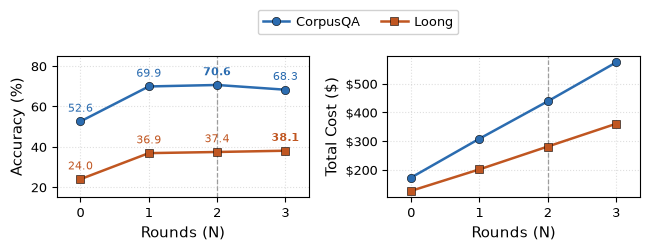

saved summary_rounds.pdf


In [30]:
FIG_DIR = paths.FIGURES_DIR / "cross"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# (label, scoped per-inference frame, se-index) — 0 = S (CorpusQA 0/1 accuracy), 1 = EM (Loong perfect rate).
_SR_BENCH = [("CorpusQA", cq_real, 0), ("Loong", loong_real, 1)]
_SR_STYLE = {"CorpusQA": (BENCH_COLOR["CorpusQA"], "o"), "Loong": (BENCH_COLOR["Loong"], "s")}   # per-BENCHMARK (both lines are our method)
_SR_VALUES = [0, 1, 2, 3]

_sr_data = {}
for _name, _df, _si in _SR_BENCH:
    _acc, _usd, _ns = [], [], []
    for _sr in _SR_VALUES:
        _g = _df[(_df["source"] == "method") & (_df["method"] == GROUNDED_METHOD)
                 & (_df["variant"] == "default") & (_df["summary_rounds"] == _sr)
                 & (_df["model"] == report.PRIMARY_MODEL)]
        _acc.append(report._se(_g)[_si] * 100 if len(_g) else float("nan"))
        _usd.append(_g.loc[_g["status"] == "ok", "usd"].sum() if len(_g) else float("nan"))
        _ns.append(len(_g))
    _sr_data[_name] = {"acc": _acc, "usd": _usd, "n": _ns}
    print(f"{_name:9s} n per N={_ns}  acc={[round(a,2) for a in _acc]}  usd={[round(u) for u in _usd]}")

fig, (axA, axC) = plt.subplots(1, 2, figsize=(6.6, 2.15))
for _ax, _key, _ylab in [(axA, "acc", "Accuracy (%)"), (axC, "usd", "Total Cost ($)")]:
    for _name, _, _ in _SR_BENCH:
        _c, _mk = _SR_STYLE[_name]
        _ax.plot(_SR_VALUES, _sr_data[_name][_key], marker=_mk, color=_c, markeredgecolor="black",
                 markeredgewidth=0.4, markersize=6, linewidth=1.8, label=_name, zorder=3)
    _ax.axvline(GROUNDED_SR, color="#9a9a9a", ls="--", lw=0.9, zorder=1)   # the pinned default (N = 2)
    _ax.set_xlabel("Rounds (N)", fontsize=11)
    _ax.set_ylabel(_ylab, fontsize=11)
    _ax.set_xticks(_SR_VALUES)
    _ax.set_xlim(-0.35, 3.35)          # breathing room so the endpoint value labels don't hit the spines
    _ax.tick_params(labelsize=9.5)
    _ax.grid(True, ls=":", alpha=0.4, zorder=0)
# Print each point's exact accuracy above its dot, in the line's colour; the WINNER (that
# benchmark's best N) is bold, so the peak reads at a glance — CorpusQA peaks at N=2, Loong at N=3.
for _name, _, _ in _SR_BENCH:
    _c, _ = _SR_STYLE[_name]
    _vals = _sr_data[_name]["acc"]
    _best = max(range(len(_vals)), key=lambda i: _vals[i])
    for _i, _v in enumerate(_vals):
        axA.annotate(f"{_v:.1f}", (_SR_VALUES[_i], _v), textcoords="offset points", xytext=(0, 7),
                     ha="center", fontsize=8, color=_c,
                     fontweight="bold" if _i == _best else "normal", zorder=4)
axA.set_yticks([20, 40, 60, 80])                           # matplotlib picks only 2 ticks otherwise
axA.set_ylim(15, 85)                                       # headroom so the value labels don't clip
axC.yaxis.set_major_formatter(FuncFormatter(_kdollar))     # compact $ ticks, same style as the cost figure

fig.tight_layout()
fig.legend(*axA.get_legend_handles_labels(), loc="lower center", bbox_to_anchor=(0.55, 1.0),
           ncol=2, fontsize=9.5, frameon=True, framealpha=0.9, handletextpad=0.5, columnspacing=1.6)
fig.savefig(FIG_DIR / "summary_rounds.pdf", bbox_inches="tight")           # the paper's figure
fig.savefig(FIG_DIR / "summary_rounds.png", dpi=300, bbox_inches="tight")  # local check render
display(fig)
plt.close(fig)
print("saved summary_rounds.pdf")